In [34]:
import os

import pandas as pd
import scanpy as sc

import DeconV as dv

In [35]:
wrkdir = os.path.join(os.path.expanduser("~"), "Documents", "dev", "fimm", "data", "pbmc")

In [36]:
# Download files from NCBI GEO 'GSM4041646' and bulk sample 'GSE136148_Bulk_rawgenetable'
adata = sc.read_h5ad(os.path.join(wrkdir, "sc.h5ad"))
bulk = pd.read_table(os.path.join(wrkdir, "bulk.tsv"), index_col=0)

adata.var.set_index("gene_ids", inplace=True)
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

bulk.index = bulk.index.str.split(".").str[0]
bulk = bulk[~bulk.index.duplicated(keep=False)]

adata = dv.tl.combine(adata, bulk)

adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=None)
adata.layers["ncounts"] = adata.X.copy()
sc.pp.log1p(adata)


scRNA-seq data - cells: 2625, genes: 13331
bulk RNA-seq data - samples: 12, genes: 13331


In [37]:
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

/home/lutrarutra/.pyenv/versions/3.10.9/envs/lst/lib/python3.10/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


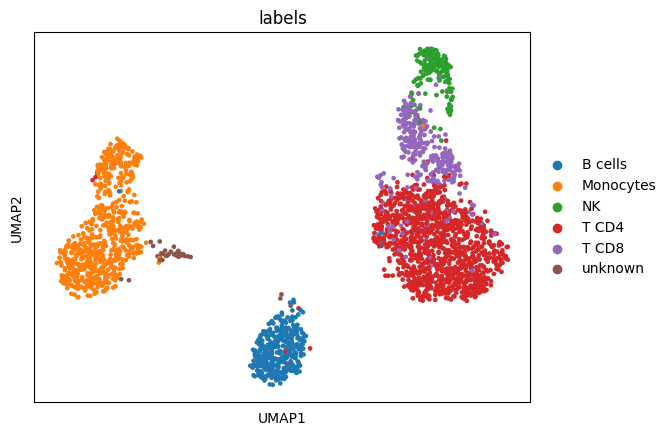

In [38]:
sc.tl.leiden(adata, resolution=0.1)
# adata.obs["cell_type"] = adata.obs["leiden"].astype("category").cat.rename_categories(["MDA-MB-438", "MCF7", "HF"])
adata.obs.drop(columns=["leiden"], inplace=True)
sc.pl.umap(adata, color=["labels"])

In [39]:
# MuSiC
# bulk
bulk.to_csv(os.path.join("data", "pbmc_bulk_data.csv"))
# count matrix
pd.DataFrame(adata.layers["counts"].A, index=adata.obs_names, columns=adata.var_names).to_csv(os.path.join("data", "pbmc_counts.csv"))
# cell types
adata.obs["sampleID"] = 0
adata.obs["sampleID"].iloc[0] = 1
adata.obs["labels"] = adata.obs["labels"].cat.rename_categories({"unknown":"UNKWN"})
adata.obs[["labels", "sampleID"]].to_csv(os.path.join("data", "pbmc_celltypes.csv"))